In [74]:
import warnings
warnings.filterwarnings('ignore')

In [76]:
import numpy as np
import pandas as pd

In [78]:
import os
import pickle

In [80]:
import time

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

In [84]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [86]:
books=pd.read_csv('books.csv', low_memory=False)
users=pd.read_csv('users.csv')
ratings=pd.read_csv('ratings.csv')

In [87]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [90]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [92]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [94]:
print(ratings['Book-Rating'].max(), ratings['Book-Rating'].unique())

ratings.head(3)

10 [ 0  5  3  6  8  7 10  9  4  1  2]


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


In [96]:
print(f'Book dataframe\'s shape is {books.shape}')
print('Ratings\'s shape is: {}'.format(ratings.shape))

Book dataframe's shape is (271360, 8)
Ratings's shape is: (1149780, 3)


In [98]:
print('Null values in books dataframe are as follows:')
print('**********************************************')
print(books.isnull().sum())

Null values in books dataframe are as follows:
**********************************************
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


In [100]:
print('Null values in ratings dataframe are as follows:')
print('************************************************')
print(ratings.isnull().sum())

Null values in ratings dataframe are as follows:
************************************************
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [102]:
print('Number of duplicated values in books_df')
print('***************************************')

print(books.duplicated().sum())

Number of duplicated values in books_df
***************************************
0


In [104]:
print('Number of duplicated values in ratings_df')
print('*****************************************')

print(ratings.duplicated().sum())

Number of duplicated values in ratings_df
*****************************************
0


In [106]:
display(books)
display(ratings)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [108]:
df = books.merge(ratings, on='ISBN')

user_prune = df.groupby('User-ID')['Book-Rating'].count() > 20
user_and_rating = user_prune[user_prune].index # outputs the User-IDs for users that rate more than 100 books

filtered_rating = df[df['User-ID'].isin(user_and_rating)]

rating_prune = df.groupby('Book-Title')['Book-Rating'].count() >= 10
famous_books = rating_prune[rating_prune].index

final_rating = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [112]:
book_pivot_table = final_rating.pivot_table(index='Book-Title', columns='User-ID', values='Book-Rating')

book_pivot_table.fillna(0, inplace=True)

print('datset dimension: ', (book_pivot_table.shape))
book_pivot_table.head(5)

datset dimension:  (17439, 6355)


User-ID,242,243,254,383,388,408,446,487,503,507,...,278194,278202,278221,278356,278418,278535,278582,278633,278843,278851
Book-Title,,,,,,,,,,,,,,,,,,,,,
"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Good Wives: Image and Reality in the Lives of Women in Northern New England, 1650-1750",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback)),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Q-Space (Star Trek The Next Generation, Book 47)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Q-Zone (Star Trek The Next Generation, Book 48)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
tsvd = TruncatedSVD(n_components=200, random_state=42) # reduce the dimentionality - similar to PCA
book_pivot_table_tsvd = tsvd.fit_transform(book_pivot_table)

In [114]:
print('Original number of features before dimensionality reduction: ', (book_pivot_table.count(), len(book_pivot_table.columns)))
print('Number of features after dimensionality reduction: ', book_pivot_table_tsvd.shape)
print('Explained variance ratio: ', tsvd.explained_variance_ratio_[0:1500].sum())

Original number of features before dimensionality reduction:  (User-ID
242       17439
243       17439
254       17439
383       17439
388       17439
          ...  
278535    17439
278582    17439
278633    17439
278843    17439
278851    17439
Length: 6355, dtype: int64, 6355)
Number of features after dimensionality reduction:  (17439, 200)
Explained variance ratio:  0.33867510218307667


In [115]:
indices = book_pivot_table.index # all the user IDs

book_rating_clustering = pd.DataFrame(data=book_pivot_table_tsvd, index=indices)
print(book_rating_clustering.shape)
book_rating_clustering.head(10)

(17439, 200)


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
Book-Title,,,,,,,,,,,,,,,,,,,,,
"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",0.167937,0.012726,0.210086,0.031595,-0.024395,0.213004,0.051416,0.045815,0.248314,-0.149980,...,-0.151844,-0.183795,0.119053,-0.098249,0.356433,-0.041056,0.347218,0.232265,0.027919,0.023459
"Good Wives: Image and Reality in the Lives of Women in Northern New England, 1650-1750",0.265040,-0.057272,0.557787,0.266702,0.432637,0.122330,-0.323602,-0.027507,-0.101337,-0.350027,...,-0.043960,0.154284,0.461538,-0.612312,0.124080,-0.160340,-0.067116,0.061608,0.005522,-0.077278
Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback)),2.251168,8.541110,-1.364869,1.520418,0.717424,-0.029344,-0.021838,0.108022,-0.982481,0.025287,...,0.429424,-0.118680,-0.057354,0.428357,-0.252971,0.029161,0.599438,-0.323779,0.366281,0.776010
"Q-Space (Star Trek The Next Generation, Book 47)",0.246641,-0.028449,0.312414,0.175606,0.031936,0.013130,-0.429294,-0.070982,0.121046,-0.714857,...,0.400442,-0.314215,0.279185,-0.058290,0.521757,0.222727,-0.296932,-0.262474,-0.131811,0.074628
"Q-Zone (Star Trek The Next Generation, Book 48)",0.028067,-0.008158,0.039669,-0.005902,-0.019392,0.012224,-0.047094,-0.003755,-0.006469,-0.032341,...,-0.016623,-0.352434,0.326145,-0.009970,-0.154231,0.078848,0.143197,-0.087176,0.084808,0.536233
!Yo!,0.201469,-0.024743,0.334570,0.188829,-0.063270,-0.031714,-0.515228,-0.037137,0.046575,0.109430,...,0.373810,-0.439850,0.272159,-0.224295,0.024446,-0.233912,0.321957,-0.187429,0.335533,0.053782
'Salem's Lot,1.494951,-0.046264,3.187849,0.364970,-1.388643,-4.961555,-3.604833,0.720147,-1.506181,-0.340481,...,-1.619818,-0.649735,-0.053266,0.732679,1.113224,0.729900,-0.596034,-0.859502,0.240516,-0.372532
...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR,0.392119,-0.061948,0.710182,0.319340,-0.267548,0.226882,-0.289142,0.932043,0.177752,-0.228781,...,-0.517952,0.065063,-0.278992,-0.679130,0.028226,0.314874,-0.643359,-0.481284,-0.404538,-0.206530
01-01-00: A Novel of the Millennium,6.727741,-2.307183,-3.518448,-0.352766,0.424176,-0.054753,-0.098461,0.275968,0.017168,0.120947,...,-0.036666,0.024705,0.020462,-0.007732,-0.030960,-0.047659,-0.015075,-0.017817,0.023624,0.067752


In [116]:
train_rate, test_rate = train_test_split(book_rating_clustering, test_size=0.2, random_state=42)
print(f'Traing set shape: {train_rate.shape}')
print('Testing set shape: {}'.format(test_rate.shape))

Traing set shape: (13951, 200)
Testing set shape: (3488, 200)


In [117]:
test_rate.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
Book-Title,,,,,,,,,,,,,,,,,,,,,
The Burning Man,0.728855,0.005075,1.350782,0.932732,-0.859630,0.652764,-0.082720,-1.470632,-0.930469,2.309993,...,0.322527,-0.309053,0.827626,-0.145209,0.012760,0.408043,0.150317,-0.095225,-0.257146,-0.058406
The Watsons Go to Birmingham - 1963 (Yearling Newbery),0.002271,0.001257,0.009811,0.004626,-0.003036,0.012354,0.002421,-0.008006,0.008440,-0.027434,...,0.014755,-0.003664,0.035209,-0.003322,0.049702,0.031060,-0.005416,0.018904,-0.020165,-0.020250
A Royal Duty,0.553033,0.657922,0.370231,0.663467,-0.069377,-0.033133,0.298988,-1.601031,0.509432,-0.627998,...,-0.126073,0.018064,0.345693,-0.079390,0.182526,0.005839,0.036566,-0.313098,-0.093570,0.001583
101 Great American Poems (Dover Thrift Editions),0.130608,-0.036764,0.208009,0.103224,0.184707,0.033003,-0.197133,-0.109394,0.089685,0.077072,...,-0.081891,-0.119631,0.035546,-0.308683,0.129265,0.237251,-0.331975,0.080660,0.018378,-0.220953
Garden of Rama,5.896413,-2.017666,-3.058453,-0.300959,0.352225,-0.069695,-0.066653,0.200974,0.041388,0.089597,...,-0.067508,0.022831,-0.023271,-0.033468,0.041738,-0.019466,-0.008588,-0.036340,-0.019578,0.057466


In [118]:
indices = test_rate.index
test_set_rating = book_pivot_table.loc[indices] # .loc[] for label-based indexing and .iloc[] for position-based indexing.
test_set_rating.head()

User-ID,242,243,254,383,388,408,446,487,503,507,...,278194,278202,278221,278356,278418,278535,278582,278633,278843,278851
Book-Title,,,,,,,,,,,,,,,,,,,,,
The Burning Man,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Watsons Go to Birmingham - 1963 (Yearling Newbery),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Royal Duty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101 Great American Poems (Dover Thrift Editions),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Garden of Rama,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [119]:
test_set_rating.isnull().count()

User-ID
242       3488
243       3488
254       3488
383       3488
388       3488
          ... 
278535    3488
278582    3488
278633    3488
278843    3488
278851    3488
Length: 6355, dtype: int64

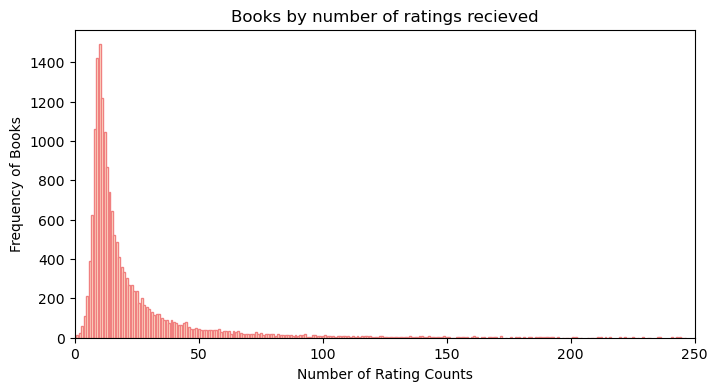

In [120]:
#Exploratory Data Analysis

# Group the data by each book and counts how many ratings each book has recieved
book_rating_counts = final_rating.groupby('Book-Title')['Book-Rating'].count()

# Calculate how many books fall into each rating count category and then sorts these counts
rating_frequencies = book_rating_counts.value_counts().sort_index()

# Plotting the histogram
plt.figure(figsize=(8, 4))
plt.bar(rating_frequencies[:500].index, rating_frequencies[:500].values, color='Cornsilk', edgecolor='LightCoral')

plt.xlim(0, 250)

# Adding titles and labels
plt.title('Books by number of ratings recieved')
plt.xlabel('Number of Rating Counts')
plt.ylabel('Frequency of Books')

# Display the plot
plt.show()

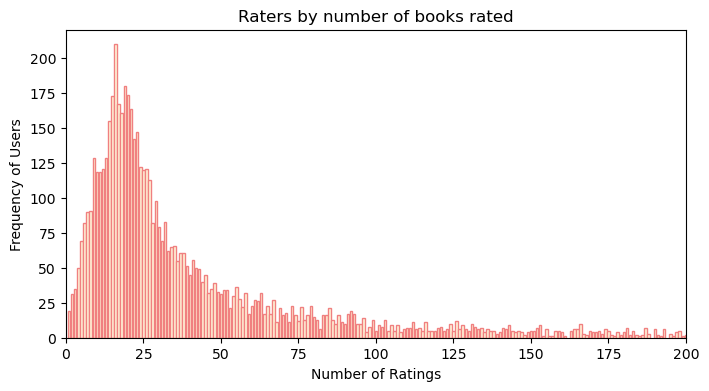

In [121]:
# Group the data by each user and counts how many ratings each user has given
user_rating_counts = final_rating.groupby('User-ID')['Book-Rating'].count()

# Calculate how many users fall into each rating count category and then sorts these counts
rating_frequencies = user_rating_counts.value_counts().sort_index()


# Plotting the histogram
plt.figure(figsize=(8, 4))
plt.bar(rating_frequencies.index, rating_frequencies.values, color='Cornsilk', edgecolor='LightCoral')

plt.xlim(0, 200)

# Adding titles and labels
plt.title('Raters by number of books rated')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency of Users')

# Display the plot
plt.show()

1108


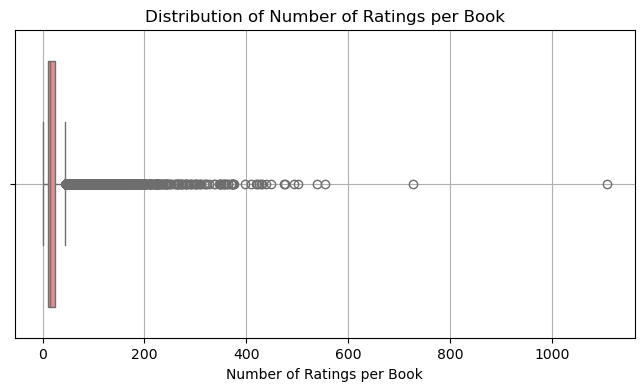

In [122]:
# Count the number of ratings per book
book_rating_counts = final_rating.groupby('Book-Title')['Book-Rating'].count().reset_index()

# Rename columns for clarity
book_rating_counts.columns = ['Book-Title', 'Number of Ratings']

print(book_rating_counts['Number of Ratings'].max())

# Plotting the boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x='Number of Ratings', data=book_rating_counts, color='LightCoral')
plt.xlabel('Number of Ratings per Book')
plt.title('Distribution of Number of Ratings per Book')
plt.grid(True)
plt.show()


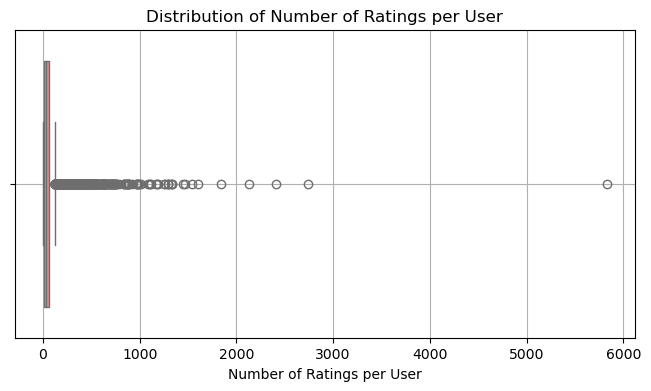

In [123]:
# Count the number of ratings per user
user_rating_counts = final_rating.groupby('User-ID')['Book-Rating'].count().reset_index()

# Rename columns for clarity
user_rating_counts.columns = ['User-ID', 'Number of Ratings']

# Plotting the boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x='Number of Ratings', data=user_rating_counts, color='LightCoral')
plt.xlabel('Number of Ratings per User')
plt.title('Distribution of Number of Ratings per User')
plt.grid(True)
plt.show()

In [ ]:
# Define the range of cluster numbers to test
cluster_range = range(2, 10)  # Example range from 2 to 20 clusters
times = []

# Measure running time for each number of clusters
for n_clusters in cluster_range:
    start_time = time.time()

    kmeans = KMeans(n_clusters)
    model = kmeans.fit(train_rate)

    end_time = time.time()
    elapsed_time = end_time - start_time
    times.append(elapsed_time)
    print(f"Number of clusters: {n_clusters}, Time taken: {elapsed_time:.2f} seconds")

In [ ]:
# Fit the KMeans model
clusterer_KMeans = KMeans(n_clusters=6, random_state=42).fit(train_rate)

# Transform the data to get predictions
preds_KMeans = clusterer_KMeans.predict(train_rate)

unique_labels = np.unique(preds_KMeans)
print(f"Number of clusters: {len(unique_labels)}")

KMeans_score = silhouette_score(train_rate, preds_KMeans)
print('Silhouette score for k-mean approach: ', KMeans_score)

In [ ]:
# clustering books
clusterer_GM = GaussianMixture(n_components=6, random_state=42).fit(train_rate)
preds_GM = clusterer_GM.predict(train_rate)

GM_score = silhouette_score(train_rate, preds_GM)
print('Silhouette score for Gaussian Mixture approach: ', GM_score)

In [ ]:
indices = train_rate.index
preds = pd.DataFrame(data=preds_GM, columns=['cluster'], index=indices)
print(preds.shape)
for i in range(7):
  print('cluster ', i+1, ':', preds[preds['cluster'] == i+1].count())
preds.head()

In [ ]:
test_preds = clusterer_GM.predict(test_rate)
test_indices = test_rate.index
test_cluster = pd.DataFrame(data=test_preds, columns=['cluster'], index=test_indices)

Test_GM_score = silhouette_score(test_rate, test_preds)

print(f'Silhouette Score for the test set is: {Test_GM_score}')
test_cluster.head()

In [206]:
def recommend_books(book_name, book_pivot_table, preds, n_recommendations=10):
    # Convert the book name to lowercase and split it into words for partial matching
    keywords = book_name.lower().split()
    
    # Initialize a list to store matched book recommendations
    recommendations = []

    for title in book_pivot_table.index:
        # Check if any keyword is present in the book title
        if any(keyword in title.lower() for keyword in keywords):
            recommendations.append(title)

    # If we have fewer than `n_recommendations`, add more based on similarity
    if len(recommendations) < n_recommendations:
        try:
            # Find the exact index of the input book_name in the pivot table
            index = np.where(book_pivot_table.index == book_name)[0][0]
            # Sort similar items by similarity score
            similar_items = sorted(list(enumerate(preds[index])), key=lambda x: x[1], reverse=True)
            
            # Add similar books to recommendations until reaching `n_recommendations`
            for i in similar_items:
                if len(recommendations) >= n_recommendations:
                    break
                similar_title = book_pivot_table.index[i[0]]
                if similar_title not in recommendations:
                    recommendations.append(similar_title)
        except IndexError:
            print(f"'{book_name}' not found in the book pivot table.")

    # Limit the output to n_recommendations
    return recommendations[:n_recommendations]

In [252]:
# Example usage
book_name = 'Harry Potter and the Chamber of Secrets (Book 2)'
recommended_books = recommend_books(book_name, book_pivot_table, preds, n_recommendations=15)
print(f"Books similar to '{book_name}':")
for i, book in enumerate(recommended_books):
    print(f"{i+1}. {book}")

Books similar to 'Harry Potter and the Chamber of Secrets (Book 2)':
1.  Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth
2.  Good Wives: Image and Reality in the Lives of Women in Northern New England, 1650-1750
3.  Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback))
4.  Q-Space (Star Trek The Next Generation, Book 47)
5.  Q-Zone (Star Trek The Next Generation, Book 48)
6. ...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR
7. 01-01-00: A Novel of the Millennium
8. 01-01-00: The Novel of the Millennium
9. 1421: The Year China Discovered America
10. 1812 (The American Story)
11. 1916: A Novel of the Irish Rebellion (Irish Century)
12. 20,000 Leagues Under the Sea
13. 20,000 Leagues Under the Sea (Wordsworth Collection)
14. 21st Century Wicca: A Young Witch's Guide to Living the Magical Life (Citadel Library of the Mystic Arts)
15. 253: The Print Remix


In [ ]:
pickle.dump(book_pivot_table, open('book_pivot_table.pkl', 'wb'))
pickle.dump(books, open('books.pkl', 'wb'))
pickle.dump(recommended_books, open('recommended_books.pkl', 'wb'))
pickle.dump(preds, open('predicted_clusters.pkl', 'wb'))